## First Milestone ##
### Beyond praying for rain: Quantifying natural recovery outcomes for the Great Salt Lake  ###


#### Participants: ####
Clara Garcia | u6060670 | clara.garcia@utah.edu<br>
Lindsey McGuire | u1204515 | lindsey.mcguire@utah.edu<br>
Kim Lanaghen | u1210825 | kim.lanaghen@utah.edu<br>
Mason Buckman | u1466966 | mason.buckman@utah.edu<br>


- Peer Feedback
    - Take into consideration the impact of the Bear, Weber, and Jordan Rivers as a major feeders to the Great Salt Lake, as
their flow likely plays a significant role in lake level changes.
    - Consider incorporating precipitation data from additional weather stations across Northern Utah,
beyond the primary region of interest.
    - Look into other variables that drive water consumption and influence lake levels, such as
agricultural use (e.g., alfalfa farming).
    - What does a given level of rainfall predict about how much the lake grew or shrank? What other
variables contributed to changes that aren't captured linearly?
    - To narrow down the methodology, start by selecting a few key variables to focus on, then let the
data guide which methods to use and what further questions to ask.
    - Consider comparing the Great Salt Lake to similar lakes that have experienced drought or
shrinkage, such as those in the Middle East or California, to help validate findings.
    - Compare model to/replicate other studies that have been done. Then, show the difference
between models.
    - With the data that we have, can we get similar data to the model that was already
done?
    - Why was a particular model chosen for prior studies? How are we looking at things
differently?
    - What does that rainfall mean for everything else? Flooding/ice age, when in history have the
conditions be closest to those types of events? Consider sampling those conditions into the
model.
    - Be mindful of spurious correlations.

**General Update**

Moving through peer evalutations, we received feedback noting that our original plan failed to account for water flowing in from major tributaries and increased human consumption. We originally wanted to only work with precipitation and snowpack data, but because snowpack can tie into tributary flow data, we decided to pivot and work with tributary flow and precipitation data. We will stick with our origial data source for precipitation data, but we will use the USGS information from the Salt Lake Hydromapper Current Conditions page (https://webapps.usgs.gov/gsl/data.html). This helped us hoene in on what analysis we will do later on, and slightly altered the questions we wanted to answer. 

### New Questions:

1. Can we model future lake outcomes using k-NN sample bootstrapping? 
    - This utilizes historical data in a completely different fashion than what we originally thought we were going to pursue before. 

### 1. Project Description
The Great Salt Lake has experienced a prolonged decline in water levels over the past few decades, reaching a historic low in recent years. The impacts of a shrinking lake are far-reaching. As the Great Salt Lake’s water levels decrease, salinity rises, disrupting the ecosystems and the industries tied to the lake. Most concerning is the possibility of toxic dust and sediments blanketing the surrounding region and communities throughout the state as more lakebed area is slowly exposed. With these concerns in mind, recent public conversations have involved “praying for rain” and hopeful wishes for a healthier lake and wetter climate as part of a tangible solution. Moreover, these discussions raise questions around the role that increased natural precipitation might play in restoring the lake to healthier conditions. With this project we want to investigate ways of predicting lake level outcomes using historical data and a k-NN classifier.

### 2. Ethical Data Concerns
Our five sources are all federal government agencies with their data in the public domain, so restrictions are minimal to none for the types of data we are extracting. No API keys were necessary for data extraction. The data use terms were reviewed to ensure responsible use. We also abided by the data retrieval rule of one year of data per request separated by at least 0.2 seconds for the NOAA data.

### 3. Data Description

USGS GSL Hydromapper (NEW)
- Started scraping data from the site that has major tributary inflow and outflow data. 
- Our inflow tributaries include three major tributaries, the Bear River (57% of inflow), Weber River (20% of inflow), and the Jordan River (16% of inflow). 
    - There are small caveats associated with the Jordan River as it is diverted through a surplus canal in Salt Lake City, but we are working with the data we can scrape from the USGS site. 

USGS National Water Information System (NWIS) REST API
- Lake water surface elevation at the Saltair Boat Harbor monitoring station (1950-2024)
- Documentation available at https://waterservices.usgs.gov/
- No account required to access the API. Reviewed the terms at https://www.usgs.gov/information-policies-and-instructions/acknowledging-or-crediting-usgs to ensure proper use and crediting of data used
Natural Resources Conservation Service (NRCS) SNOTEL network

Historical snow water equivalent data (relevant snowpack -> runoff estimate) (1980-2026)
- Downloadable CSV available at: https://wcc.sc.egov.usda.gov/reportGenerator/
- Reviewed documentation and terms to ensure proper use

NOAA Climate Data Online (CDO) REST API
- Historical climate and precipitation data (1950-2024)
- Will primarily use the Salt Lake City Airport monitoring station
- Reviewed documentation and terms to ensure proper use https://www.ncei.noaa.gov/cdo-web/webservices/v2. A free account is required to obtain an API token, which has been obtained. The API has a restriction of one year of data per call, so years will be looped through with a rate-limiting pause between requests to remain in compliance.

Great Salt Lake Elevation Area Volume Tables (NEW)
- Contains elevation-area-volume relationships for the Great Salt Lake
- Downloadable CSV avilable at: https://www.sciencebase.gov/catalog/item/6467b42fd34ec11ae4a8afb1, labeled as Great_Salt_Lake_2023_ElevAreaVolume_total.csv
- Root, J.C., 2023, Half-meter topobathymetric elevation model and elevation-area-volume tables for Great Salt Lake, Utah, 2002-2016: U.S. Geological Survey data release, https://doi.org/10.5066/P9DGG75W.
___
### 4. Data Acquisition
Data was obtained from the USGS API through an API request and was combined into two CSVs, one for Inflow sources and one for outflow streams going back to 1950. Lake level and precipitation data were collected through separate API requests via the NWIS REST API and NOAA CDO REST API respectively and combined into separate CSV files. The data for both precipitation and lake level stretched back to 1950, simlar to ouflow data. Historical snowpack data was directly downloaded to CSV format from a USDA website going back to 1980. We were able to obtain data from each of our sources in a monthly format which allowed us to look into consolidating into a single data frame. After reviewing our final data sets, we learned that lake outflow data refers to water flow through small, shallow areas of the lake such as Farmington Bay and Willard Bay. As a result we decided not to include this file in our final data frame. To calculate and create our own evaporation dataset, we used Bigalke et al.'s (2025) mass-balance equation as a model as well as Great Salt Lake Elevation-Area-Volume tables from the USGS Science Data Catalog.

### 5. Data Cleaning
Thankfully much of the data obtained was already fairly clean, however we took the following steps to ensure compatible structure for eventually combining everything into a single dataframe:
- Created month / year tracking columns for each constituent dataframe
- Renamed columns to be more descriptive or to have similar names across data frames
- Unified column data types (string dates -> DateTimes, numeric conversions, units, etc.)

---
### 6. Combine all data into one dataframe
Ultimately, we were able to combine the snowpack, lake level, inflow, precipitation, and evaporation data all into a single continuous dataframe which was exported as a new CSV file. Each major category became a column in the final dataframe all binned by month and year. The snowpack column was the only column containing NaN values which occur prior to 1980 (before readings).
___
### 7. Methods

**New Analysis Methods:**

***k-NN Bootstrap Inspired by Lall and Sharma:***

We happened to come across this paper demonostrating a different way of predicting lake level outcomes using historical data. Insead of using k-NN in its predicted fashion of classification based on proximity, it will be used to predict a future outcome based on the feature reads we are given in that particular month or year. We will start with the reads we have right now, then the feature values will be compared to years past. This is where k-NN comes into play. We will use k-NN to compare where we are now to the data in years past to find year N, a year in which the feature reads are closest to where we are now. From there we will observe lake reads in year N+1 which we will detgermine as the outcome of th features combined in year N. 

For this k-NN analysis, we want to use precipitation data, inflow and outflow streams, and general human consumption metrics to create a model that takes into account all of the major players in lake level affectors. But because of the granularity of the model, we will have to take into account model penalties for adding more variables. 

We are choosing this method instead of linear regression for a number of reasons. Due to the large number of variables that contribute to overall lake level. Lake level has not been consistently decreasing at a constant level, so using a simple linear regression would be counterintuitive based on simply visually guaging the plot of lake level over time. 

https://webapps.usgs.gov/gsl/data.html

## Data Processing Code ##

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
import json
import time

In [3]:
## Perform API request to USGS for lake level data and save the response as a json file
# USGS address for lake level data
usgs_url = "https://waterservices.usgs.gov/nwis/dv/"

# Parameters for API request - we want the lake level data for the Great Salt Lake at Saltair Boat Harbor, UT (USGS-10010000) from 1950 to 2024
usgs_params = {
    "format": "json",    # we want it returned in json
    "sites": "10010000",    # Great Salt Lake at Saltair Boat Harbor, UT - USGS-10010000
    "parameterCd": "62614",   # code for lake water surface elevation
    "startDT": "1950-01-01",   # start and end dates
    "endDT": "2024-12-31"
}

# Getting data from the api address with the params we set above
usgs_response = requests.get(usgs_url, params=usgs_params)
#converting to json
usgs_data = usgs_response.json()

# Save the full json to a file for viewing/searching
with open("usgs_response.json", "w") as f:
    json.dump(usgs_data, f, indent=2)

In [4]:
## Process and Access the raw lake level data from the json response

# Entering the layers where the data lives, grabbing the first value in each list
usgs_time_series = usgs_data["value"]["timeSeries"][0]["values"][0]["value"]

# Converting to pandas dataframe
usgs_df = pd.DataFrame(usgs_time_series)

# Data exploration
print(usgs_df.head(20))
print(usgs_df.shape)

      value qualifiers                 dateTime
0   4197.15        [A]  1950-01-01T00:00:00.000
1   4197.40        [A]  1950-02-01T00:00:00.000
2   4197.90        [A]  1950-03-01T00:00:00.000
3   4198.15        [A]  1950-04-01T00:00:00.000
4   4198.35        [A]  1950-05-01T00:00:00.000
5   4198.80        [A]  1950-06-01T00:00:00.000
6   4198.65        [A]  1950-07-01T00:00:00.000
7   4198.30        [A]  1950-08-01T00:00:00.000
8   4197.90        [A]  1950-09-01T00:00:00.000
9   4197.55        [A]  1950-10-01T00:00:00.000
10  4197.60        [A]  1950-11-01T00:00:00.000
11  4197.90        [A]  1950-12-01T00:00:00.000
12  4198.30        [A]  1951-01-01T00:00:00.000
13  4198.50        [A]  1951-02-01T00:00:00.000
14  4198.95        [A]  1951-03-01T00:00:00.000
15  4199.20        [A]  1951-04-01T00:00:00.000
16  4199.45        [A]  1951-05-01T00:00:00.000
17  4199.90        [A]  1951-06-01T00:00:00.000
18  4199.55        [A]  1951-07-01T00:00:00.000
19  4199.15        [A]  1951-08-01T00:00

In [5]:
# Cleaning up the dataframe
usgs_df = usgs_df.rename(columns={"dateTime": "date", "value": "elevation_ft"})
usgs_df = usgs_df.drop(columns=["qualifiers"])

# Converting the date columns to datetime datatype
usgs_df["date"] = pd.to_datetime(usgs_df["date"])

# Converting the string elevation data to numeric
usgs_df["elevation_ft"] = pd.to_numeric(usgs_df["elevation_ft"], errors="coerce")

# Aggregating to monthly measurements
# Setting the date as the index, grouping by month ("MS" = month start), taking the average of each month, reset the index
usgs_monthly = usgs_df.set_index("date").resample("MS")["elevation_ft"].mean().reset_index()

# Adding some separate date columns for potential later use
usgs_monthly["year"] = usgs_monthly["date"].dt.year
usgs_monthly["month"] = usgs_monthly["date"].dt.month

# Save the cleaned and aggregated data to a new csv file
usgs_monthly.to_csv('lake_level_monthly.csv', index=False)

# Print info about the cleaned lake level data
print(usgs_monthly.info())

# Print a preview of the cleaned lake level data
usgs_monthly

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          900 non-null    datetime64[ns]
 1   elevation_ft  900 non-null    float64       
 2   year          900 non-null    int32         
 3   month         900 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 21.2 KB
None


,date,elevation_ft,year,month
0,1950-01-01,4197.150000,1950,1
1,1950-02-01,4197.400000,1950,2
2,1950-03-01,4197.900000,1950,3
3,1950-04-01,4198.150000,1950,4
4,1950-05-01,4198.350000,1950,5
...,...,...,...,...
895,2024-08-01,4193.232258,2024,8
896,2024-09-01,4192.660000,2024,9
897,2024-10-01,4192.316129,2024,10
898,2024-11-01,4192.183333,2024,11


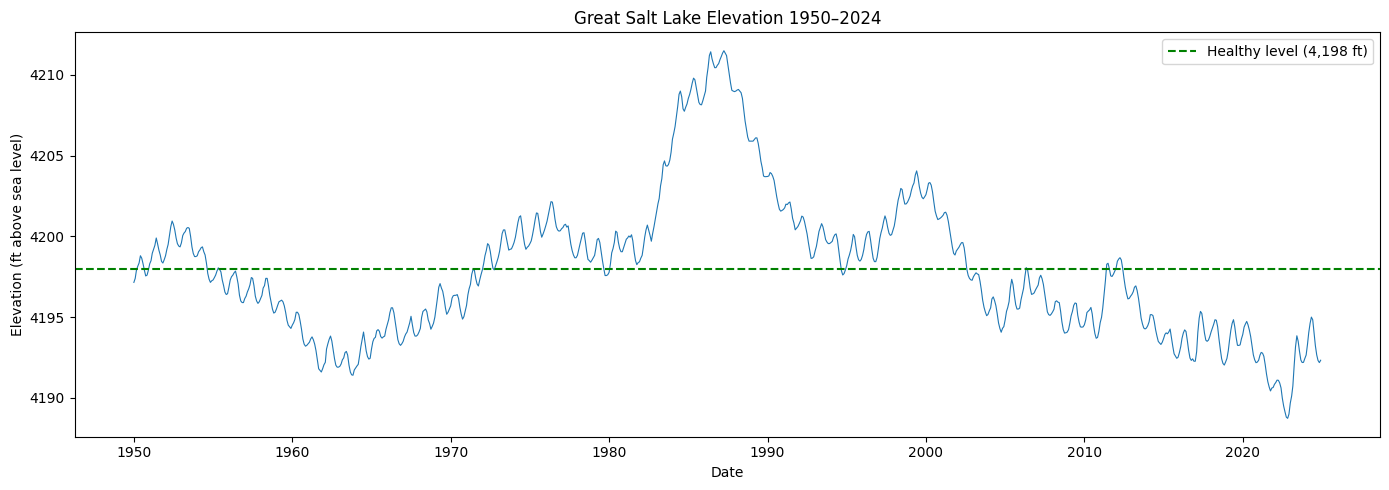

In [6]:
# Plotting lake elevation over time to see the overall trend and variability in the data

plt.figure(figsize=(14, 5))
plt.plot(usgs_monthly["date"], usgs_monthly["elevation_ft"], linewidth=0.8)
plt.axhline(y=4198, color="green", linestyle="--", label="Healthy level (4,198 ft)")
plt.title("Great Salt Lake Elevation 1950–2024")
plt.ylabel("Elevation (ft above sea level)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
## Performing API request to NOAA for precipitation data and saving the response as a json file

url = "https://www.ncei.noaa.gov/access/services/data/v1" # Newer version of API that does not require access token (different from proposal)

# NOAA only allows one year per data request, so we loop through each year and gather the data into a single list, which will be converted to a dataframe at the end
all_data = []

for year in range(1950, 2025):
    # Setting up the API request parameters
    params = {
        "dataset": "daily-summaries",
        "stations": "USW00024127",  # SLC airport station code
        "dataTypes": "PRCP", # precipitation data
        "startDate": f"{year}-01-01",   # inserting the current year for each loops date parameters
        "endDate": f"{year}-12-31",
        "format": "json",
        "units": "standard"
    }
    
    # Sending the request
    response = requests.get(url, params=params)
    
    # Checking if the request succeeded (code = 200) and if so converting the response to json data
    if response.status_code == 200:
        data = response.json()
        # Adding data from successful responses, flagging any that didn't work
        if data:
            all_data.extend(data)
            print(f"{year}: got {len(data)} records")
        else:
            print(f"{year}: no results")
    else:
        print(f"{year}: error {response.status_code} - {response.text[:100]}")

    # Adding a delay to abide by API rules
    time.sleep(0.4)

# Converting the list of precipitation data to a dataframe for exploration and cleaning
precip_df = pd.DataFrame(all_data)
print(precip_df.head())
print(precip_df.columns)

1950: got 365 records
1951: got 365 records
1952: got 366 records
1953: got 365 records
1954: got 365 records
1955: got 365 records
1956: got 366 records
1957: got 365 records
1958: got 365 records
1959: got 365 records
1960: got 366 records
1961: got 365 records
1962: got 365 records
1963: got 365 records
1964: got 366 records
1965: got 365 records
1966: got 365 records
1967: got 365 records
1968: got 366 records
1969: got 365 records
1970: got 365 records
1971: got 365 records
1972: got 366 records
1973: got 365 records
1974: got 365 records
1975: got 365 records
1976: got 366 records
1977: got 365 records
1978: got 365 records
1979: got 365 records
1980: got 366 records
1981: got 365 records
1982: got 365 records
1983: got 365 records
1984: got 366 records
1985: got 365 records
1986: got 365 records
1987: got 365 records
1988: got 366 records
1989: got 365 records
1990: got 365 records
1991: got 365 records
1992: got 366 records
1993: got 365 records
1994: got 365 records
1995: got 

In [8]:
# Cleaning up dataset, similar to NSGS cleaning steps
precip_df = precip_df.rename(columns={"DATE": "date", "PRCP": "precip_inches"})
precip_df["date"] = pd.to_datetime(precip_df["date"])
precip_df["precip_inches"] = pd.to_numeric(precip_df["precip_inches"], errors="coerce")

# Resampling to montly precipitation TOTAL (sum)
# nNote this is different than the lake level aggregation, which was the average measurement (mean)
precip_monthly = precip_df.set_index("date")["precip_inches"].resample("MS").sum().reset_index()
precip_monthly.columns = ["date", "monthly_precip_inches"]

# Add year and month columns for potential later use
precip_monthly["year"] = precip_monthly["date"].dt.year
precip_monthly["month"] = precip_monthly["date"].dt.month

# Creating CSV
precip_monthly.to_csv("precipitation_monthly.csv", index=False)

# Printing info about the cleaned and aggregated precipitation data
print(precip_monthly.info())

# Printing preview of cleaned and aggregated precipitation data
precip_monthly

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   900 non-null    datetime64[ns]
 1   monthly_precip_inches  900 non-null    float64       
 2   year                   900 non-null    int32         
 3   month                  900 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 21.2 KB
None


,date,monthly_precip_inches,year,month
0,1950-01-01,1.80,1950,1
1,1950-02-01,1.19,1950,2
2,1950-03-01,0.98,1950,3
3,1950-04-01,1.29,1950,4
4,1950-05-01,2.18,1950,5
...,...,...,...,...
895,2024-08-01,1.15,2024,8
896,2024-09-01,0.42,2024,9
897,2024-10-01,0.79,2024,10
898,2024-11-01,1.22,2024,11


In [9]:
## Covert the snowpack data from csv to dataframe and perform cleaning steps similar to the other datasets

# Creating snowpack dataframe to do some cleaning
snowpack_df = pd.read_csv('snowpack.csv', comment='#', skip_blank_lines=True)

# Data cleaning (renaming columns, converting datatypes, adding additional date cols)
snowpack_df = snowpack_df.rename(columns={"Snowbird (766) Snow Water Equivalent (in) Start of Month Values": "snow_water_equiv_in"})
snowpack_df["Date"] = pd.to_datetime(snowpack_df["Date"], format="%b %Y")
snowpack_df["snow_water_equiv_in"] = pd.to_numeric(snowpack_df["snow_water_equiv_in"], errors="coerce")
snowpack_df["year"] = snowpack_df["Date"].dt.year
snowpack_df["month"] = snowpack_df["Date"].dt.month

# Create clean csv file for snowpack
snowpack_df.to_csv('snowpack_monthly.csv')

# Printing info about the cleaned snowpack data
print(snowpack_df.info())

# Printing preview of cleaned snowpack data
snowpack_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439 entries, 0 to 438
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 439 non-null    datetime64[ns]
 1   snow_water_equiv_in  439 non-null    float64       
 2   year                 439 non-null    int32         
 3   month                439 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2)
memory usage: 10.4 KB
None


,Date,snow_water_equiv_in,year,month
0,1989-09-01,0.0,1989,9
1,1989-10-01,0.0,1989,10
2,1989-11-01,1.9,1989,11
3,1989-12-01,9.4,1989,12
4,1990-01-01,11.0,1990,1
...,...,...,...,...
434,2025-11-01,0.0,2025,11
435,2025-12-01,1.0,2025,12
436,2026-01-01,6.6,2026,1
437,2026-02-01,14.5,2026,2


In [10]:
## Compile snowpack, lake level, and precipitation data sets into a single data frame, then save to a new csv file

# Load each monthly dataframe
precipitation = pd.read_csv("precipitation_monthly.csv")
lake_level = pd.read_csv("lake_level_monthly.csv")
snowpack = pd.read_csv("snowpack_monthly.csv")

# Printed parts of the data frames to see what values overlap and where to join them
# print(snowpack.head(10), "\n")
# print(precipitation.head(10), "\n")
# print(lake_level.head(10), "\n")
# print(lake_level["year"].unique(), "\n")
# print(snowpack["year"].unique(), "\n")

# Renamed the Date column in snowpack to date for consistency
snowpack = snowpack.rename(columns={"Date": "date"})

# Removed 2025 and 2026 data in snowpack to be consistent with other dfs
snowpack = snowpack[snowpack["year"] < 2025]

# Compile the dataframe, joining precipitation with lake_level and snowpack on date, year, and month
# This join strategy assigns NaN where anything doesn't exist (i.e. before 1989 in snowpack data)
compiled_df = precipitation.merge(lake_level, on=["date", "year", "month"], how="outer") \
               .merge(snowpack, on=["date", "year", "month"], how="outer")

# Extract and order the final columns needed in the compiled dataframe
compiled_df = compiled_df[["date", "year", "month", "elevation_ft", "monthly_precip_inches", "snow_water_equiv_in"]]

# Save the final compiled dataframe as a new csv file
compiled_df.to_csv("compiled_lake_data.csv")

# Display the first ten lines of the compiled dataframe
compiled_df.tail(10)

# Note: In the snow_water_equiv_in column, the values are NaN before 1989 since there was no data before
# that time.

,date,year,month,elevation_ft,monthly_precip_inches,snow_water_equiv_in
890,2024-03-01,2024,3,4194.035484,2.08,35.8
891,2024-04-01,2024,4,4194.610000,1.51,46.9
892,2024-05-01,2024,5,4195.000000,1.45,46.1
893,2024-06-01,2024,6,4194.833333,0.31,20.4
894,2024-07-01,2024,7,4194.067742,0.08,0.0
895,2024-08-01,2024,8,4193.232258,1.15,0.0
896,2024-09-01,2024,9,4192.660000,0.42,0.0
897,2024-10-01,2024,10,4192.316129,0.79,0.0
898,2024-11-01,2024,11,4192.183333,1.22,1.0
899,2024-12-01,2024,12,4192.329032,1.12,3.6


### Data Processing for Inflow/Outflow Data

The largest hurdle with this data was figuring out how to transform the data to be able to use it when it's aggregated monthly. We decided to use acre sq ft per month as our unit when transforming the data. It was also concluded after pulling the data that the outflow bays/sites were not significant enough of a contribution, so in the end we will not be using outflow sites in our analysis.

In [11]:
import requests
import pandas as pd
from io import StringIO
import os

OUTPUT_DIR = os.path.join(os.path.expanduser("~"), "Downloads")
BASE_URL   = "https://waterservices.usgs.gov/nwis/dv/"


# Inflows  = rivers flowing INTO the lake
# Outflows = diversions / canals taking water AWAY before it reaches the lake

INFLOW_SITES = {
    "Bear River (primary, near Corinne)":  "10126000",
    "Bear River (upstream gap-fill)":      "10118000",
    "Weber River (near Plain City)":       "10141000",
    "Jordan River (Surplus Canal)":        "10170500",
    "Jordan River (1700 South)":           "10171000",
}

OUTFLOW_SITES = {
    "Bear River Canal (diversion)":        "10113500",
    "Ogden-Brigham Canal":                 "10133650",
    "Weber Basin Diversion":               "10141000",   
    "Jordan Narrows (diversion point)":    "10168000",
}

START_DATE = "1950-01-01"
END_DATE   = "2025-12-31"

In [12]:

def fetch_site(site_id):
    """Pull daily mean discharge (param 00060) for one USGS site."""
    params = {
        "format":      "rdb",        
        "sites":       site_id,
        "startDT":     START_DATE,
        "endDT":       END_DATE,
        "parameterCd": "00060",      # discharge in ft³/s
        "statCd":      "00003",      # daily mean
    }
    response = requests.get(BASE_URL, params=params, timeout=60)
    response.raise_for_status()

    # strip comment lines 
    lines = [l for l in response.text.splitlines() if not l.startswith("#")]
    if len(lines) < 3:
        print(f"  No data for site {site_id}")
        return pd.DataFrame()

    content = "\n".join([lines[0]] + lines[2:])   # header + data rows
    df = pd.read_csv(StringIO(content), sep="\t", low_memory=False)

    # find the discharge column 
    discharge_col = [c for c in df.columns if c.endswith("_00060_00003")]
    if not discharge_col:
        print(f"  No discharge column for site {site_id}")
        return pd.DataFrame()

    df = df[["datetime", discharge_col[0]]].copy()
    df.columns = ["date", "discharge_cfs"]
    df["date"]          = pd.to_datetime(df["date"], errors="coerce")
    df["discharge_cfs"] = pd.to_numeric(df["discharge_cfs"], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
    return df

#fetch all sites, print a summary

def fetch_all(site_dict, label):
    print(f"\n── Fetching {label} ──")
    results = {}
    for name, site_id in site_dict.items():
        print(f"  {name} (site {site_id}) ...", end=" ")
        df = fetch_site(site_id)
        if not df.empty:
            print(f"{len(df):,} daily records "
                  f"({df['date'].min().date()} to {df['date'].max().date()})")
        else:
            print("no data")
        results[name] = df
    return results

inflow_raw  = fetch_all(INFLOW_SITES,  "INFLOWS")
outflow_raw = fetch_all(OUTFLOW_SITES, "OUTFLOWS")


── Fetching INFLOWS ──
  Bear River (primary, near Corinne) (site 10126000) ... 25,567 daily records (1950-01-01 to 2025-12-31)
  Bear River (upstream gap-fill) (site 10118000) ... 26,178 daily records (1950-01-01 to 2023-09-30)
  Weber River (near Plain City) (site 10141000) ... 27,759 daily records (1950-01-01 to 2025-12-31)
  Jordan River (Surplus Canal) (site 10170500) ... 27,759 daily records (1950-01-01 to 2025-12-31)
  Jordan River (1700 South) (site 10171000) ... 27,759 daily records (1950-01-01 to 2025-12-31)

── Fetching OUTFLOWS ──
  Bear River Canal (diversion) (site 10113500) ... 26,482 daily records (1950-01-01 to 2025-12-31)
  Ogden-Brigham Canal (site 10133650) ... 8,456 daily records (2002-11-07 to 2025-12-31)
  Weber Basin Diversion (site 10141000) ... 27,759 daily records (1950-01-01 to 2025-12-31)
  Jordan Narrows (diversion point) (site 10168000) ... 14,119 daily records (1980-02-20 to 2025-12-31)


In [13]:
def build_monthly(raw_dict):
    """
    For each site: resample daily → monthly mean.
    Then merge all sites side-by-side on date.
    """
    monthly_frames = []
    for name, df in raw_dict.items():
        if df.empty:
            continue
        monthly = (df.set_index("date")["discharge_cfs"]
                     .resample("MS")        # MS = month-start frequency
                     .mean()
                     .rename(name)
                     .to_frame())
        monthly_frames.append(monthly)

    if not monthly_frames:
        return pd.DataFrame()

    # join all sites on date (outer join to keep all dates, even if some sites are missing)
    combined = monthly_frames[0]
    for frame in monthly_frames[1:]:
        combined = combined.join(frame, how="outer")

    combined.index.name = "date"
    combined = combined.sort_index()
    return combined

inflow_monthly  = build_monthly(inflow_raw)
outflow_monthly = build_monthly(outflow_raw)

# add a total column, save to CSV

# total monthly inflow = sum across all inflow columns (ignores NaN)
inflow_monthly["TOTAL_INFLOW_cfs"]  = inflow_monthly.sum(axis=1)
outflow_monthly["TOTAL_OUTFLOW_cfs"] = outflow_monthly.sum(axis=1)

inflow_path  = os.path.join(OUTPUT_DIR, "gsl_inflow_monthly.csv")
outflow_path = os.path.join(OUTPUT_DIR, "gsl_outflow_monthly.csv")

# quick check
print("\n── Inflow monthly (first 5 rows) ──")
print(inflow_monthly.head())

print("\n── Outflow monthly (first 5 rows) ──")
print(outflow_monthly.head())


── Inflow monthly (first 5 rows) ──
            Bear River (primary, near Corinne)  \
date                                             
1950-01-01                         2174.193548   
1950-02-01                         2594.642857   
1950-03-01                         2619.677419   
1950-04-01                         3842.000000   
1950-05-01                         4698.064516   

            Bear River (upstream gap-fill)  Weber River (near Plain City)  \
date                                                                        
1950-01-01                     2067.806452                     569.322581   
1950-02-01                     2347.500000                     659.392857   
1950-03-01                     2243.548387                     987.806452   
1950-04-01                     3629.666667                    2434.400000   
1950-05-01                     4393.225806                    3747.096774   

            Jordan River (Surplus Canal)  Jordan River (1700 South)  \
d

In [14]:
df = pd.read_csv("gsl_inflow_monthly.csv", index_col="date", parse_dates=True)

# get days in each month
days_in_month = df.index.days_in_month

# convert every column from mean cfs → acre-feet for that month
df_acft = df.multiply(days_in_month * 1.9835, axis=0)

# rename columns
df_acft.columns = [c + "_acft" for c in df_acft.columns]

df_acft.to_csv(os.path.join(OUTPUT_DIR, "gsl_inflow_monthly_acft.csv"))
print("Saved acre-feet version")
print(df_acft.head())

Saved acre-feet version
            Bear River (primary, near Corinne)_acft  \
date                                                  
1950-01-01                               133687.900   
1950-02-01                               144101.275   
1950-03-01                               161080.035   
1950-04-01                               228618.210   
1950-05-01                               288876.940   

            Bear River (upstream gap-fill)_acft  \
date                                              
1950-01-01                           127146.317   
1950-02-01                           130375.455   
1950-03-01                           137952.425   
1950-04-01                           215983.315   
1950-05-01                           270132.865   

            Weber River (near Plain City)_acft  \
date                                             
1950-01-01                          35006.7915   
1950-02-01                          36621.3605   
1950-03-01                      

### Data Processing for Evaporation Data 

We used Bigalke et al.'s (2025) mass-balance equation as a model to calculate and create our own evaporation dataset. We already had key variables such as, inflow, precipitation, and lake elevation data. In order to derive evaporation data, we needed to find the lake volume. We used the USGS Science Data Catalog to find the Great Salt Lake Elevation-Area-Volume tables, which contained elevation-area-volume relationships for the Great Salt Lake. The elevation-area-volume totals were calculated at elevation increments of 0.01 feet between 4,170–4,215 ft (Root, 2023). This data covers the historical range of lake elevations in our dataset.

We started with Bigalke et al.'s (2025) mass-balance equation for calculating lake volume changes:

    V_t = V_(t-1) + P_t × A_(t-1) + R_t − E_t × A_(t-1)
    
Then, we rearranged the equation by solving for E_t, since we opted not to use ERA5 reanalysis data as Bigalke et al. (2025) did. Instead, we used our available data to simplify the mass-balance equation to calculate month-to-month lake volume changes based on inflow, precipitation, and lake elevation. Precipitation was converted from inches to acre-feet by dividing by 12 and multiplying by the prior month's surface area in acres:

    precip_acft = (monthly_precip_inches / 12) × prior_month_surface_area

Since this conversion already accounts for the lake's prior month surface area, A_(t-1) could be eliminated from the equation, resulting in the following simplified equation:

    E_t = V_(t-1) + R_t + P_t − V_t

Where:<br>
* E_t = that month's evaporation (acre-feet)<br>
* V_(t-1) = prior month's lake volume (acre-feet)<br>
* R_t = that month's total inflow (acre-feet)<br>
* P_t = that month's precipitation on the lake surface (acre-feet)<br>
* V_t = current month's lake volume (acre-feet)

In [15]:
import pandas as pd 
import numpy as np

# Lake elevation and precipitation (monthly)
elev_prec_df = pd.read_csv('compiled_lake_data.csv')
# Infow acft
inflow_acft_df = pd.read_csv('gsl_inflow_monthly_acft.csv')

# Bigalke et al. (2025) original equation:
# V_t = V_(t-1) + P_t × A_(t-1) + R_t − E_t × A_(t-1)
# https://agupubs.onlinelibrary.wiley.com/doi/epdf/10.1029/2024GL112154
# Rearranged and simplified equation:
# E_t = V_(t-1) + R_t + P_t − V_t

In [16]:
# To calculate how much water is in the lake (not just height/elevation), need to convert elevation to volume acre-feet
# Import stage-volume curve for GSL: 
# Tells us how much water is in the lake at an elevetion of 4197ft (~above sea level, because the lake is wider/narrower at different places)
# https://www.sciencebase.gov/catalog/item/6467b42fd34ec11ae4a8afb1
stage_vol_df = pd.read_csv('GSL_ElevAreaVolume_total.csv')
print(stage_vol_df.head())
print(stage_vol_df.columns)

   elev_ft_NAVD88  elev_ft_NGVD29  area_ft2  area_m2  area_km2  area_mi2  \
0         4170.00         4166.52       0.0        0       0.0       0.0   
1         4170.01         4166.53       0.0        0       0.0       0.0   
2         4170.02         4166.54       0.0        0       0.0       0.0   
3         4170.03         4166.55       0.0        0       0.0       0.0   
4         4170.04         4166.56       0.0        0       0.0       0.0   

   area_acre  volume_ft3  volume_m3  volume_km3  volume_mi3  volume_acreft  
0        0.0         0.0        0.0         0.0         0.0            0.0  
1        0.0         0.0        0.0         0.0         0.0            0.0  
2        0.0         0.0        0.0         0.0         0.0            0.0  
3        0.0         0.0        0.0         0.0         0.0            0.0  
4        0.0         0.0        0.0         0.0         0.0            0.0  
Index(['elev_ft_NAVD88', 'elev_ft_NGVD29', 'area_ft2', 'area_m2', 'area_km2',
   

In [17]:
# Reload original data to start clean
elev_prec_df = pd.read_csv('compiled_lake_data.csv')
# Round elevation to 2 decimal places to match the stage-volume curve
elev_prec_df['elevation_ft'] = elev_prec_df['elevation_ft'].round(2)
# Match each lake elevation in elev_prec_df to its corresponding volume and surface area in stage_vol_df
elev_prec_df = elev_prec_df.merge(
    # Grab these columns from the stage-volume table
    stage_vol_df[['elev_ft_NGVD29', 'volume_acreft', 'area_acre']],
    # Match rows where elevation_ft == elev_ft_NGVD29 
    # (NGVD29 = at mean sea level taken in 1929)
    left_on = 'elevation_ft',
    right_on = 'elev_ft_NGVD29',
    # Keep all rows from elev_prec_df
    how = 'left'
)
elev_prec_df.head()

,Unnamed: 0,date,year,month,elevation_ft,monthly_precip_inches,snow_water_equiv_in,elev_ft_NGVD29,volume_acreft,area_acre
0,0,1950-01-01,1950,1,4197.15,1.80,NaN,4197.15,13013628.81,864498.36
1,1,1950-02-01,1950,2,4197.40,1.19,NaN,4197.40,13231625.08,879251.73
2,2,1950-03-01,1950,3,4197.90,0.98,NaN,4197.90,13677742.99,905185.46
3,3,1950-04-01,1950,4,4198.15,1.29,NaN,4198.15,13905660.50,918138.01
4,4,1950-05-01,1950,5,4198.35,2.18,NaN,4198.35,14090506.69,928507.42


In [18]:
# Shift surface area and volume one row to get prior month values, to match Bigalke et al. (2025)
# Use prior month surface area (A_(t-1))
elev_prec_df['area_acre_prior'] = elev_prec_df['area_acre'].shift(1)
# Calculate V_(t-1) by grabing volume from the previous row 
elev_prec_df['prior_month_vol_acft'] = elev_prec_df['volume_acreft'].shift(1)
elev_prec_df.head()

,Unnamed: 0,date,year,month,elevation_ft,monthly_precip_inches,snow_water_equiv_in,elev_ft_NGVD29,volume_acreft,area_acre,area_acre_prior,prior_month_vol_acft
0,0,1950-01-01,1950,1,4197.15,1.80,NaN,4197.15,13013628.81,864498.36,NaN,NaN
1,1,1950-02-01,1950,2,4197.40,1.19,NaN,4197.40,13231625.08,879251.73,864498.36,13013628.81
2,2,1950-03-01,1950,3,4197.90,0.98,NaN,4197.90,13677742.99,905185.46,879251.73,13231625.08
3,3,1950-04-01,1950,4,4198.15,1.29,NaN,4198.15,13905660.50,918138.01,905185.46,13677742.99
4,4,1950-05-01,1950,5,4198.35,2.18,NaN,4198.35,14090506.69,928507.42,918138.01,13905660.50


In [19]:
# Convert precipitation from inches to acre-feet 
# 12 inches in a ft 
elev_prec_df['precip_acreft'] = (elev_prec_df['monthly_precip_inches'] / 12) * elev_prec_df['area_acre_prior']
elev_prec_df.head()

,Unnamed: 0,date,year,month,elevation_ft,monthly_precip_inches,snow_water_equiv_in,elev_ft_NGVD29,volume_acreft,area_acre,area_acre_prior,prior_month_vol_acft,precip_acreft
0,0,1950-01-01,1950,1,4197.15,1.80,NaN,4197.15,13013628.81,864498.36,NaN,NaN,NaN
1,1,1950-02-01,1950,2,4197.40,1.19,NaN,4197.40,13231625.08,879251.73,864498.36,13013628.81,85729.420700
2,2,1950-03-01,1950,3,4197.90,0.98,NaN,4197.90,13677742.99,905185.46,879251.73,13231625.08,71805.557950
3,3,1950-04-01,1950,4,4198.15,1.29,NaN,4198.15,13905660.50,918138.01,905185.46,13677742.99,97307.436950
4,4,1950-05-01,1950,5,4198.35,2.18,NaN,4198.35,14090506.69,928507.42,918138.01,13905660.50,166795.071817


In [20]:
# Datetime: convert date columns so they match when merged 
elev_prec_df['date'] = pd.to_datetime(elev_prec_df['date'])
inflow_acft_df['date'] = pd.to_datetime(inflow_acft_df['date'])

# Merge inflow data with main dataframe (elevation and precipitation)
elev_prec_df = elev_prec_df.merge(
    #grab only the date and total inflow column
    inflow_acft_df[['date', 'TOTAL_INFLOW_cfs_acft']],
    #match rows wherre the date is the same
    on = 'date',
    # Keep rows from elev_prec_df if nothing matches
    how = 'left'
)
elev_prec_df.head()

,Unnamed: 0,date,year,month,elevation_ft,monthly_precip_inches,snow_water_equiv_in,elev_ft_NGVD29,volume_acreft,area_acre,area_acre_prior,prior_month_vol_acft,precip_acreft,TOTAL_INFLOW_cfs_acft
0,0,1950-01-01,1950,1,4197.15,1.80,NaN,4197.15,13013628.81,864498.36,NaN,NaN,NaN,311399.5825
1,1,1950-02-01,1950,2,4197.40,1.19,NaN,4197.40,13231625.08,879251.73,864498.36,13013628.81,85729.420700,330234.8985
2,2,1950-03-01,1950,3,4197.90,0.98,NaN,4197.90,13677742.99,905185.46,879251.73,13231625.08,71805.557950,378388.3280
3,3,1950-04-01,1950,4,4198.15,1.29,NaN,4198.15,13905660.50,918138.01,905185.46,13677742.99,97307.436950,607916.9645
4,4,1950-05-01,1950,5,4198.35,2.18,NaN,4198.35,14090506.69,928507.42,918138.01,13905660.50,166795.071817,811463.7345


In [21]:
# Calculate evaporation using the mass-balance equation
# E_t = V_(t-1) + R_t + P_t - V_t
elev_prec_df['evaporation_acreft'] = (
    elev_prec_df['prior_month_vol_acft']      # V_(t-1)
    + elev_prec_df['TOTAL_INFLOW_cfs_acft']  # R_t
    + elev_prec_df['precip_acreft']          # P_t
    - elev_prec_df['volume_acreft']          # V_t
)

print(elev_prec_df[['date', 'prior_month_vol_acft', 'TOTAL_INFLOW_cfs_acft', 
                     'precip_acreft', 'volume_acreft', 
                     'evaporation_acreft']].head())

        date  prior_month_vol_acft  TOTAL_INFLOW_cfs_acft  precip_acreft  \
0 1950-01-01                   NaN            311399.5825            NaN   
1 1950-02-01           13013628.81            330234.8985   85729.420700   
2 1950-03-01           13231625.08            378388.3280   71805.557950   
3 1950-04-01           13677742.99            607916.9645   97307.436950   
4 1950-05-01           13905660.50            811463.7345  166795.071817   

   volume_acreft  evaporation_acreft  
0    13013628.81                 NaN  
1    13231625.08       197968.049200  
2    13677742.99         4075.975950  
3    13905660.50       477306.891450  
4    14090506.69       793412.616317  


In [22]:
# Drop the first row since V_(t-1) is NaN for January 1950, there is no previous year data 
evaporation_data = elev_prec_df.dropna(subset = ['evaporation_acreft'])
# Save to CSV
evaporation_data.to_csv('evaporation_data.csv', index = False)

print(evaporation_data.head())
print(f'Total rows: {len(evaporation_data)}')

   Unnamed: 0       date  year  month  elevation_ft  monthly_precip_inches  \
1           1 1950-02-01  1950      2       4197.40                   1.19   
2           2 1950-03-01  1950      3       4197.90                   0.98   
3           3 1950-04-01  1950      4       4198.15                   1.29   
4           4 1950-05-01  1950      5       4198.35                   2.18   
5           5 1950-06-01  1950      6       4198.80                   0.16   

   snow_water_equiv_in  elev_ft_NGVD29  volume_acreft  area_acre  \
1                  NaN         4197.40    13231625.08  879251.73   
2                  NaN         4197.90    13677742.99  905185.46   
3                  NaN         4198.15    13905660.50  918138.01   
4                  NaN         4198.35    14090506.69  928507.42   
5                  NaN         4198.80    14513327.20  951733.99   

   area_acre_prior  prior_month_vol_acft  precip_acreft  \
1        864498.36           13013628.81   85729.420700   
2   

## Initial Data Exploration and Analysis ##

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

#import data (includes elevation, snowpack, total inflow, and calculated evaporation)
gsl_monthly_df = pd.read_csv('evaporation_data.csv')
#import tributary inflow for Bear River, Jordan River, and Weber River
inflow_df = pd.read_csv('gsl_inflow_monthly_acft.csv')

#convert date columns to datetime so they match when merged
gsl_monthly_df['date'] = pd.to_datetime(gsl_monthly_df['date'])
inflow_df['date'] = pd.to_datetime(inflow_df['date'])

#merge individual river columns into comprehensive_df
gsl_monthly_df = gsl_monthly_df.merge(
    #grab individual river columns from inflow dataset
    inflow_df[['date', 
               'Bear River (primary, near Corinne)_acft',
               'Bear River (upstream gap-fill)_acft',
               'Weber River (near Plain City)_acft',
               'Jordan River (Surplus Canal)_acft',
               'Jordan River (1700 South)_acft']],
    on ='date',
    how ='left'
)

#get rid of duplicates
gsl_monthly_df = gsl_monthly_df.drop(columns=[
    'Unnamed: 0',                          #leftover row index from saving to CSV
    'elev_ft_NGVD29',                      #duplicate of elevation_ft
    'Bear River (upstream gap-fill)_acft'  #duplicate of primary Bear River
])

#remane columns to be consistent and informative
gsl_monthly_df = gsl_monthly_df.rename(columns ={
    'TOTAL_INFLOW_cfs_acft': 'total_inflow_cfs_acft',
    'Bear River (primary, near Corinne)_acft': 'bear_river_acft',
    'Weber River (near Plain City)_acft': 'weber_river_acft',
    'Jordan River (Surplus Canal)_acft': 'jordan_river_surplus_acft',
    'Jordan River (1700 South)_acft': 'jordan_river_1700_acft',
    'monthly_precip_inches': 'monthly_precip_in',
    'area_acre': 'SA_ac',          #length x width
    'area_acre_prior': 'SA_prior_month_ac',
    'volume_acreft': 'volume_acft',
    'precip_acreft': 'precip_acft',
    'evaporation_acreft': 'evaporation_acft',
})

print(gsl_monthly_df.head())
print(gsl_monthly_df.columns)

#save csv
gsl_monthly_df.to_csv('gsl_monthly_df.csv', index = False)

        date  year  month  elevation_ft  monthly_precip_in  \
0 1950-02-01  1950      2       4197.40               1.19   
1 1950-03-01  1950      3       4197.90               0.98   
2 1950-04-01  1950      4       4198.15               1.29   
3 1950-05-01  1950      5       4198.35               2.18   
4 1950-06-01  1950      6       4198.80               0.16   

   snow_water_equiv_in  volume_acft      SA_ac  SA_prior_month_ac  \
0                  NaN  13231625.08  879251.73          864498.36   
1                  NaN  13677742.99  905185.46          879251.73   
2                  NaN  13905660.50  918138.01          905185.46   
3                  NaN  14090506.69  928507.42          918138.01   
4                  NaN  14513327.20  951733.99          928507.42   

   prior_month_vol_acft    precip_acft  total_inflow_cfs_acft  \
0           13013628.81   85729.420700            330234.8985   
1           13231625.08   71805.557950            378388.3280   
2           13677

### **1. Water Level Trends**
   
The line-graph shows the Great Salt Lake's water elevation has changed drastically over the past 74 years. The lake peaked around 1987 at its highest level, then steadily declined to a record low in 2022. The zigzag pattern throughout likely reflects seasonal patterns of snowmelt/precipitation raising the lake elevation in the spring and evaporation bringing it down in the summer. 

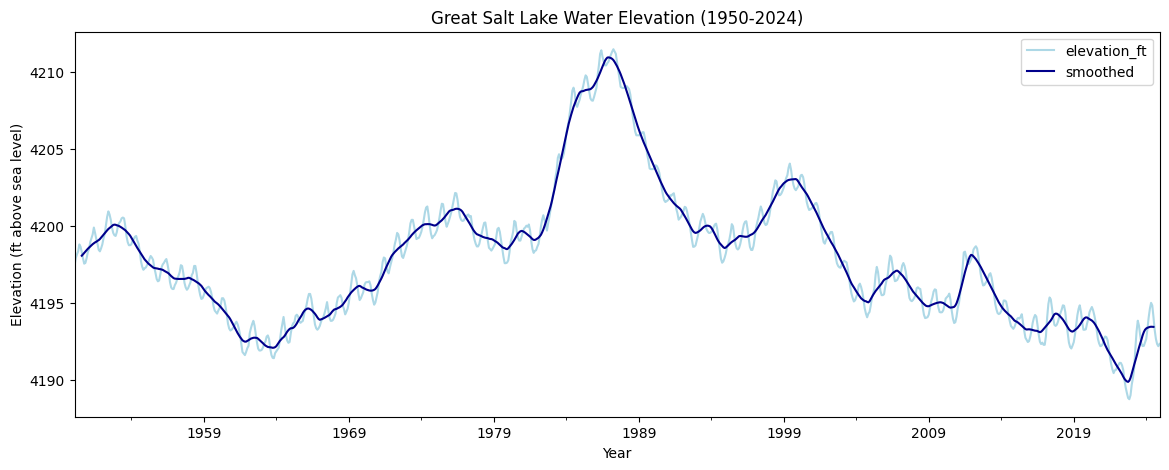

In [24]:
#Water elevation over time in a standard line graph 
#calculate 12-month rolling avg (to reduce noise for better visualization of data)
gsl_monthly_df['smoothed'] = gsl_monthly_df['elevation_ft'].rolling(window = 12, center = True).mean()

gsl_monthly_df.plot(
    x = 'date', 
    y = ['elevation_ft', 'smoothed'], 
    figsize = (14, 5),
    title = 'Great Salt Lake Water Elevation (1950-2024)',
    color = ['lightblue', 'darkblue']
)

plt.ylabel('Elevation (ft above sea level)')
plt.xlabel('Year')
plt.show()

### **2. Water Changes by Source Over Time**
   
*Tributary Data*<br>
The Bear River brings in the most water to the Great Salt Lake, consistently over time. There was a large amount of water going into the lake during the mid-1980s, then gradually returned to lower levels after that. Some data may be missing or estimated in the early years of the record, like the bear_river data in the early 1950s, which is something worth looking into and how it might affect the analysis. 

*Precipitation Data*<br>
Precipitation remained relatively stable over time with no clear long-term trend up or down. The mid-1980s stand out as a notably wetter period, consistent with the inflow spike also seen in the tributary data. 

*Evaporation Data*<br>
Water leaving the lake through evaporation also jumped in the mid-1980s, which makes sense because the lake was fuller and bigger, so more water was exposed to the sun and air. The negative values in this data are unusual and worth looking into before moving forward.

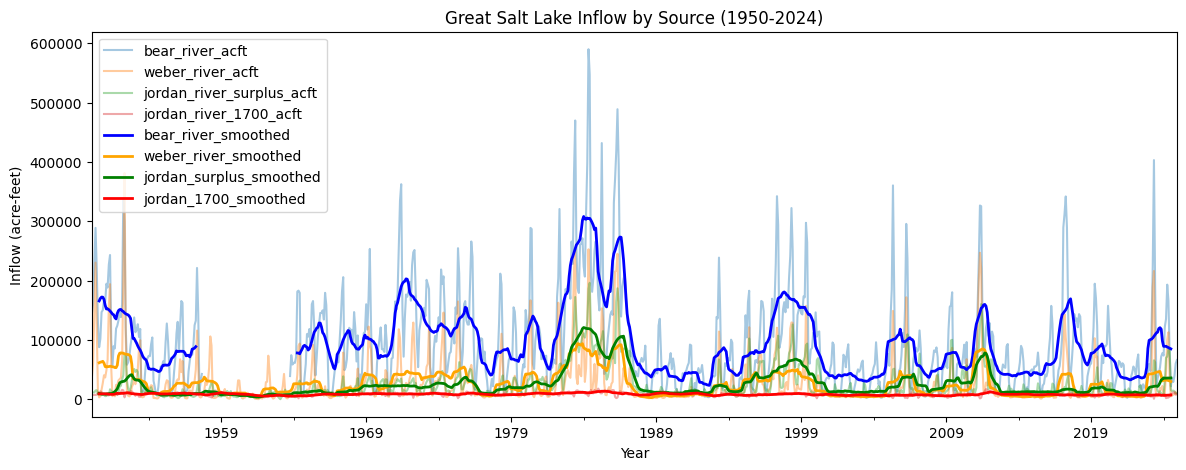

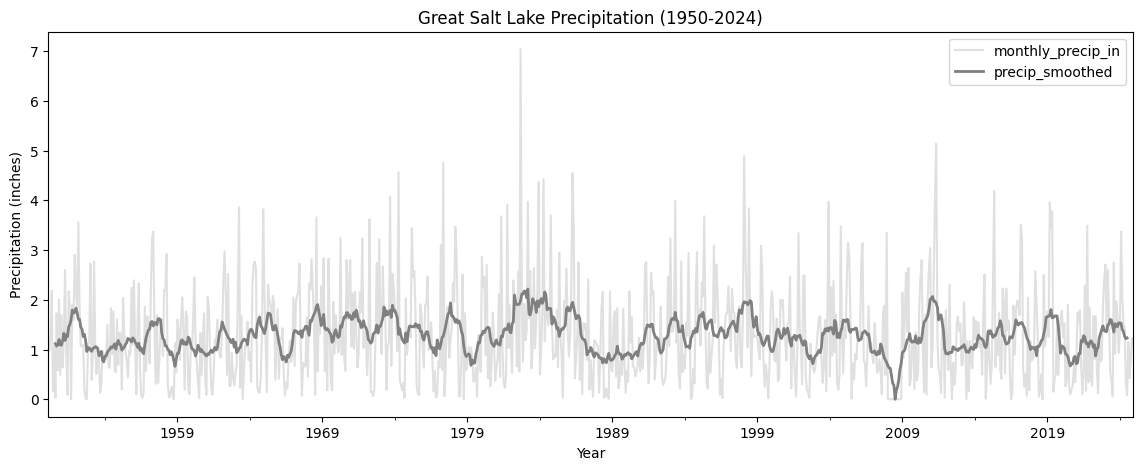

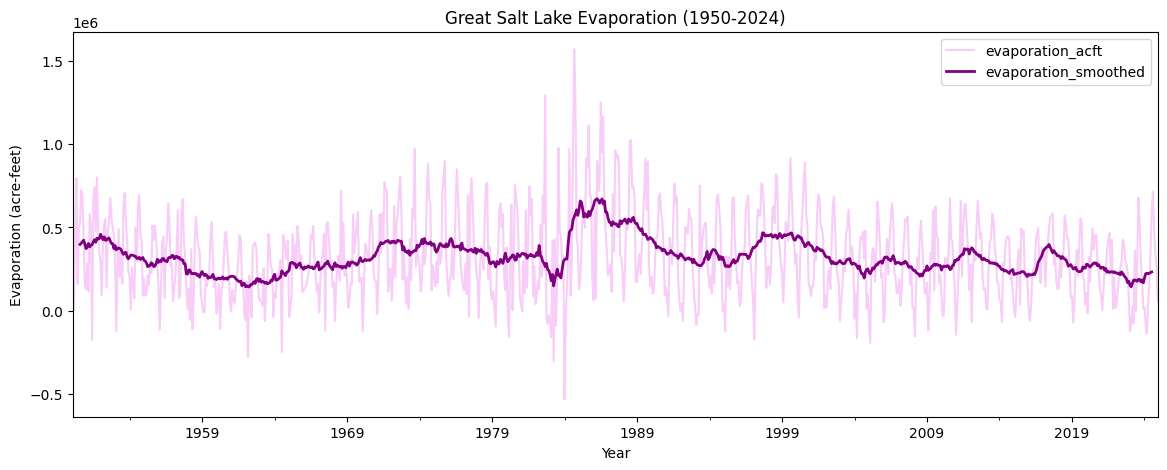

In [25]:
#calculate 12-month rolling avgs (to reduce noise for better visualization of data)
gsl_monthly_df['bear_river_smoothed'] = gsl_monthly_df['bear_river_acft'].rolling(window = 12, center= True).mean()
gsl_monthly_df['weber_river_smoothed'] = gsl_monthly_df['weber_river_acft'].rolling(window = 12, center = True).mean()
gsl_monthly_df['jordan_surplus_smoothed'] = gsl_monthly_df['jordan_river_surplus_acft'].rolling(window = 12, center = True).mean()
gsl_monthly_df['jordan_1700_smoothed'] = gsl_monthly_df['jordan_river_1700_acft'].rolling(window = 12, center = True).mean()
gsl_monthly_df['precip_smoothed'] = gsl_monthly_df['monthly_precip_in'].rolling(window = 12, center = True).mean()
gsl_monthly_df['evaporation_smoothed'] = gsl_monthly_df['evaporation_acft'].rolling(window = 12, center = True).mean()

# Plot each tributary (river inflow) source over time
gsl_monthly_df.plot(
    x = 'date',
    y = ['bear_river_acft', 'weber_river_acft', 'jordan_river_surplus_acft', 'jordan_river_1700_acft'],
    figsize = (14, 5),
    alpha = 0.4,
    title = 'Great Salt Lake Inflow by Source (1950-2024)'
)
gsl_monthly_df.plot(
    x = 'date',
    y = ['bear_river_smoothed', 'weber_river_smoothed', 'jordan_surplus_smoothed', 'jordan_1700_smoothed'],
    color = ['blue', 'orange', 'green', 'red'],
    linewidth = 2,
    ax = plt.gca()            #draw on top of current plot 
)
plt.ylabel('Inflow (acre-feet)')
plt.xlabel('Year')
plt.show()

# Plot precipitation over time
gsl_monthly_df.plot(
    x = 'date',
    y = 'monthly_precip_in',
    figsize = (14, 5),
    color = 'lightgray',
    alpha = 0.7,
    title='Great Salt Lake Precipitation (1950-2024)'
)
gsl_monthly_df.plot(
    x = 'date',
    y = 'precip_smoothed',
    color = 'gray',
    linewidth = 2,
    ax = plt.gca(),
)
plt.ylabel('Precipitation (inches)')
plt.xlabel('Year')
plt.show()

# Plot evaporation over time
gsl_monthly_df.plot(
    x = 'date',
    y = 'evaporation_acft',
    figsize = (14, 5),
    color = 'violet',
    alpha = 0.4,
    title = 'Great Salt Lake Evaporation (1950-2024)'
)
gsl_monthly_df.plot(
    x = 'date',
    y = 'evaporation_smoothed',
    color = 'purple',
    linewidth = 2,
    ax = plt.gca()
)
plt.ylabel('Evaporation (acre-feet)')
plt.xlabel('Year')
plt.show()

### **3. Lake Elevation vs Precipitation**

The scatter plot shows no clear relationship between lake elevation and monthly precipitation. Most months received between 0 and 2 inches of rain, yet the lake's water level varied widely regardless of how much rain fell that month. When the dots are colored by year, older decades show up at higher water levels while more recent years sit consistently lower, regarless of how much it rained. This suggests the lake has been shrinking due to reasons beyond monthly rainfall. 

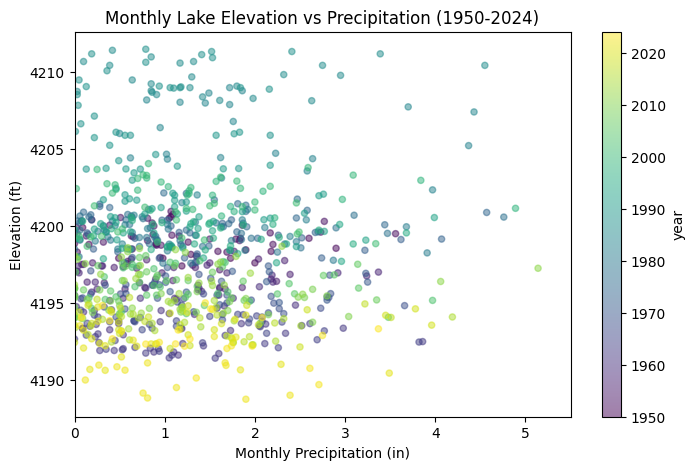

In [26]:
#scatter plot: precipitation vs GSL elevation
gsl_monthly_df.plot.scatter(
    x = 'monthly_precip_in', 
    y ='elevation_ft',
    c = 'year',               #color by year 
    colormap = 'viridis', 
    figsize = (8, 5), 
    title = 'Monthly Lake Elevation vs Precipitation (1950-2024)', 
    alpha = 0.5
)
plt.ylabel('Elevation (ft)')
plt.xlabel('Monthly Precipitation (in)')
plt.xlim(0, 5.5)              #limit x-axis to 5.5 inches (to visualize data better)
plt.show()

### **4. Descriptive Statistics**

*Summary Statistics*<br>
The Great Salt Lake averaged a water level of 4,197.94 feet over the record, ranging from a low of 4,188.73 feet to a high of 4,211.50 feet, with an average monthly rainfall of 1.28 inches. The Bear River was the largest source of water flowing into the lake, averaging 94,993 acre-feet per month, followed by the Weber River and the two Jordan River measurements. Some months show negative evaporation values which suggests the calculation may not be fully accounting for all water coming in, and is worth investigating further.

*Scatterplot matrix*<br>
The scatter plot grid shows that total water flowing into the lake is mostly driven by the Bear River. Most months have low river flow with occasional large spikes, meaning big inflow events are rare but impactful. The lake's water level does not appear strongly tied to any single monthly measurement, suggesting that long term patterns matter more than what happens in any given month. We might consider aggregating yearly data for further analysis. 

*Historical Monthly Data*<br>
The bar charts show that April receives the most rainfall on average and July the least. Evaporation is highest in August and lowest in February. Rivers bring in the most water in May and the least in August and September. Looking at all three bar charts together, spring is when the most water comes in through both rain and rivers, but summer is when the most water leaves through evaporation. This means the lake is gaining and losing water at very different times of year.

*Annual Precipitation*<br>
The line chart shows annual evaporation spiked around 1986 to 1987, which was the same period the lake was at its highest level. After that, evaporation gradually decreased over time. The most recent years show some of the lowest evaporation values in the entire record. The skewness of 0.95 indicates most years had moderate evaporation, with a small number of years pulling the average upward.

In [27]:
#summary statistics for all columns (monthly)
gsl_monthly_df.describe()

,date,year,month,elevation_ft,monthly_precip_in,snow_water_equiv_in,volume_acft,SA_ac,SA_prior_month_ac,prior_month_vol_acft,...,weber_river_acft,jordan_river_surplus_acft,jordan_river_1700_acft,smoothed,bear_river_smoothed,weber_river_smoothed,jordan_surplus_smoothed,jordan_1700_smoothed,precip_smoothed,evaporation_smoothed
count,899,899.000000,899.000000,899.000000,899.000000,424.000000,8.990000e+02,8.990000e+02,8.990000e+02,8.990000e+02,...,899.000000,899.000000,899.000000,888.000000,805.000000,888.000000,888.000000,888.000000,888.000000,888.000000
mean,1987-07-02 01:10:28.698553920,1987.041157,6.506118,4197.941513,1.278910,14.687736,1.422105e+07,9.100749e+05,9.103074e+05,1.422505e+07,...,26513.439646,24591.043802,8278.300409,4197.970547,94791.461264,26209.537101,24656.895294,8278.136208,1.282022,323043.906642
min,1950-02-01 00:00:00,1950.000000,1.000000,4188.730000,0.000000,0.000000,7.215839e+06,5.775942e+05,5.775942e+05,7.215839e+06,...,184.465500,0.000000,707.554120,4189.858333,23324.802958,2642.517875,3808.964637,5134.917858,0.000000,143425.576331
25%,1968-10-16 12:00:00,1968.000000,4.000000,4194.575000,0.530000,0.000000,1.096680e+07,7.326518e+05,7.333828e+05,1.097789e+07,...,5310.325375,9146.216025,6839.207175,4194.662708,50414.784792,8174.705990,11761.584744,7178.819566,1.043958,258282.797645
50%,1987-07-01 00:00:00,1987.000000,7.000000,4197.590000,1.120000,6.550000,1.339958e+07,8.890830e+05,8.890830e+05,1.339958e+07,...,9592.206000,13539.371000,8273.178500,4197.477500,80301.997500,21098.076271,16587.018750,8177.358921,1.268333,308360.306007
75%,2006-03-16 12:00:00,2006.000000,9.500000,4200.150000,1.805000,26.150000,1.584304e+07,1.032496e+06,1.032496e+06,1.584304e+07,...,29201.087000,27637.097250,9642.785250,4200.006458,121862.768875,39212.059438,27940.618205,9234.940459,1.487292,373844.352662
max,2024-12-01 00:00:00,2024.000000,12.000000,4211.500000,7.040000,75.100000,3.048158e+07,1.426610e+06,1.426610e+06,3.048158e+07,...,381308.040000,196306.995000,17944.724500,4210.969167,308133.419167,93739.879417,120899.283750,13588.462625,2.215833,672163.280795
std,NaN,21.637566,3.451012,4.416959,0.969498,17.646694,4.507721e+06,2.096282e+05,2.094613e+05,4.505050e+06,...,41155.355182,27599.284678,2424.817757,4.362916,56362.748416,20917.467895,22148.966253,1508.040296,0.321786,98405.829280


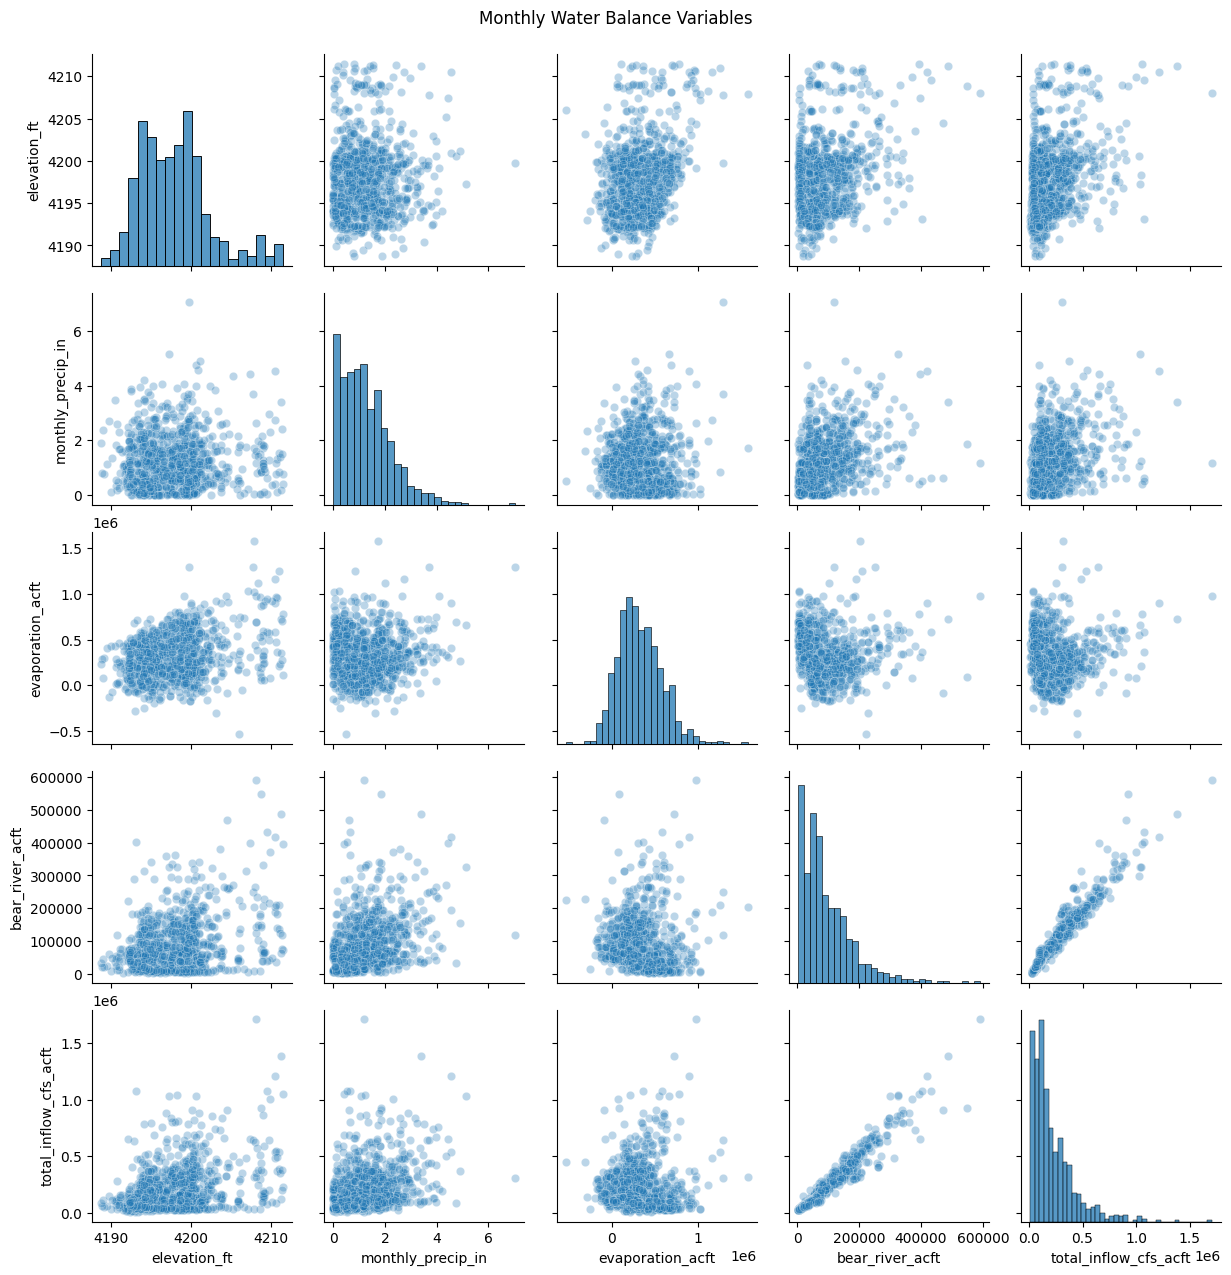

In [28]:
import seaborn as sns
#scatterplot matrix of key variables
#plot 1: main variables
sns.pairplot(gsl_monthly_df[[
    'elevation_ft',
    'monthly_precip_in',
    'evaporation_acft',
    'bear_river_acft',
    'total_inflow_cfs_acft',           
]], plot_kws = {'alpha': 0.3})
plt.suptitle('Monthly Water Balance Variables', y = 1.02)
plt.show()

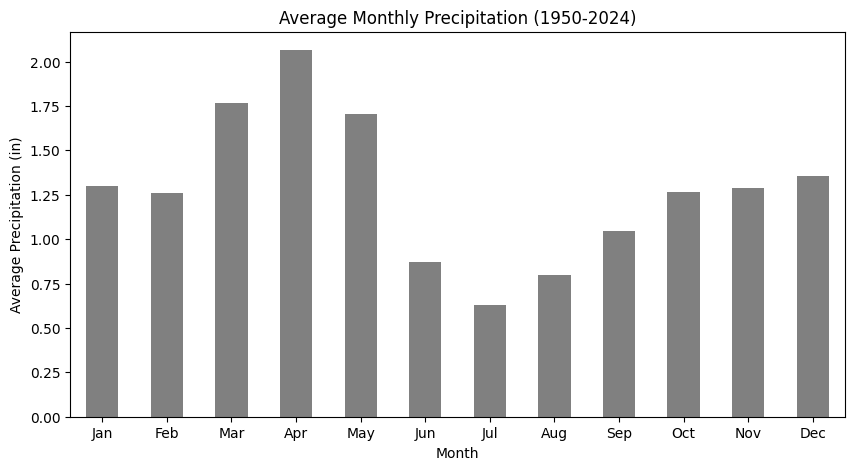

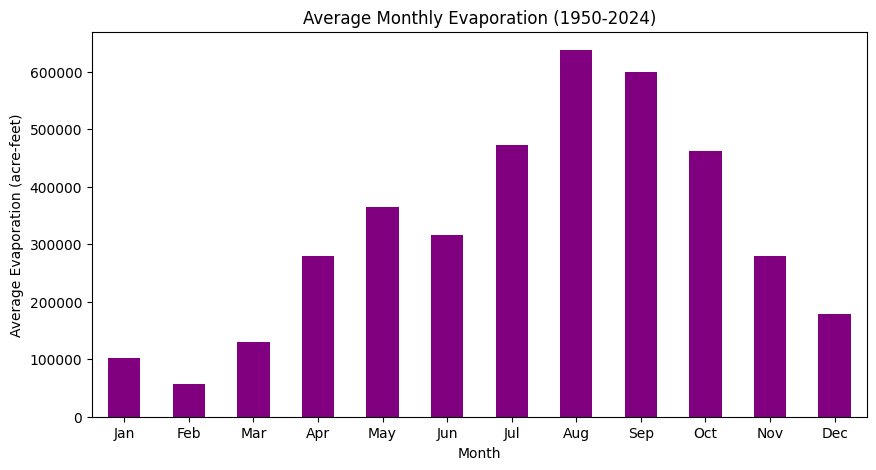

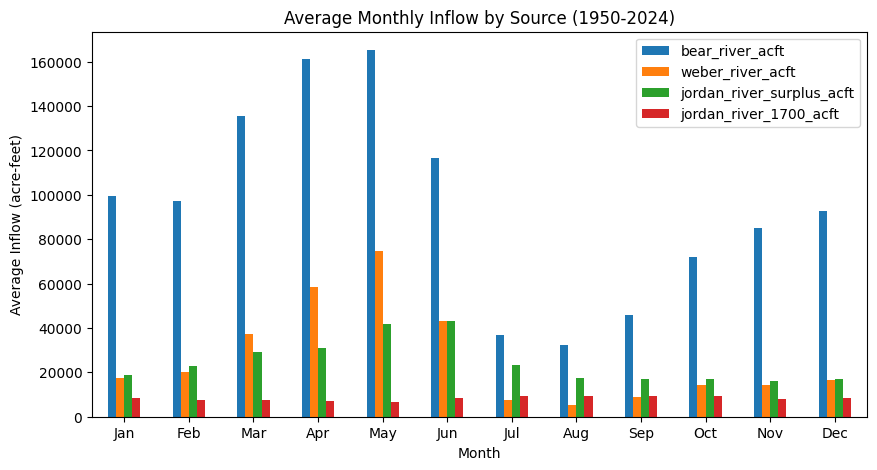

In [29]:
#determine what an average historical precipitation year looks like 
#calculate avg precipitation for each month overtime
monthly_avg_precip = gsl_monthly_df.groupby('month')['monthly_precip_in'].mean()
#plot avg precipitation by month
monthly_avg_precip.plot(kind = 'bar', figsize = (10, 5), title = 'Average Monthly Precipitation (1950-2024)', color = 'gray')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (in)')
plt.xticks(
    ticks = range(12), 
    labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], 
    rotation = 0
)
plt.show()

#calculate avg evaporation for each month overtime
monthly_avg_evap = gsl_monthly_df.groupby('month')['evaporation_acft'].mean()
#plot avg evaporation by month
monthly_avg_evap.plot(kind = 'bar', figsize = (10, 5), title = 'Average Monthly Evaporation (1950-2024)',color = 'purple')
plt.xlabel('Month')
plt.ylabel('Average Evaporation (acre-feet)')
plt.xticks(
    ticks = range(12), 
    labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], 
    rotation = 0
)
plt.show()

#calculate avg inflow for each month overtime
monthly_avg_inflow = gsl_monthly_df.groupby('month')[['bear_river_acft','weber_river_acft','jordan_river_surplus_acft','jordan_river_1700_acft']].mean()

#plot avg inflow by month
monthly_avg_inflow.plot(kind = 'bar', figsize = (10, 5), title = 'Average Monthly Inflow by Source (1950-2024)')
plt.xlabel('Month')
plt.ylabel('Average Inflow (acre-feet)')
plt.xticks(
    ticks = range(12),
    labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation = 0 
)
plt.legend()
plt.show()

Evap skewness: 0.9272187563877909


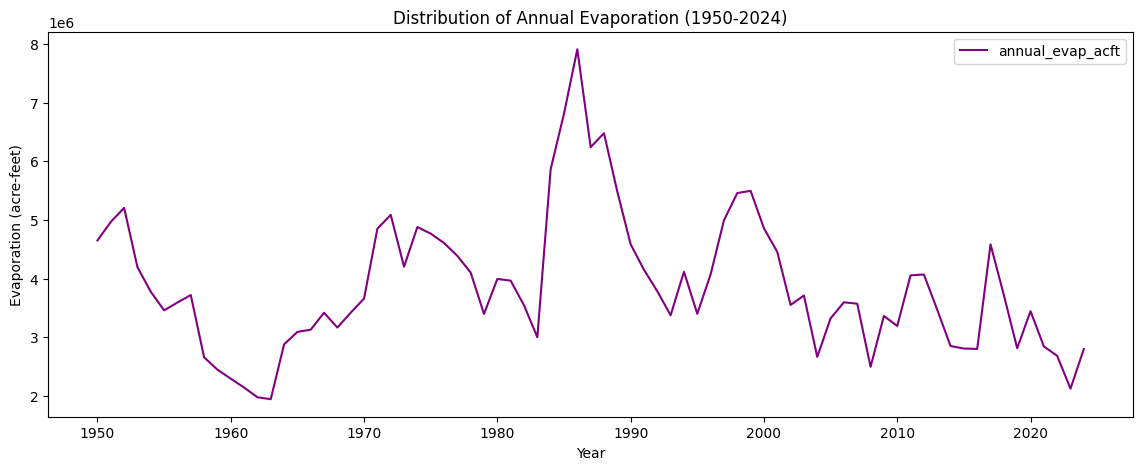

In [30]:
#calculate annual evaporation
annual_evap = gsl_monthly_df.groupby('year')['evaporation_acft'].sum().reset_index()
annual_evap.columns = ['year', 'annual_evap_acft']
#skewness
print('Evap skewness:', annual_evap['annual_evap_acft'].skew())

#plot distribution
annual_evap.plot(
    x = 'year',
    y = 'annual_evap_acft',
    figsize = (14, 5),
    title = 'Annual Evaporation Over Time (1950-2024)',
    color = 'purple'
)
# plot distribution
plt.title('Distribution of Annual Evaporation (1950-2024)')
plt.ylabel('Evaporation (acre-feet)')
plt.xlabel('Year')
plt.show()

### **5. Total Inflow vs Snowpack**

The scatter plot shows that when there is more snow build up in the mountains during winter, more water tends to flow into the lake. This pattern can be seen in the plot where the dots shift higher as you move from left to right. However the pattern is not perfectly linear, meaning that snow is not the only variable that determines how much water reaches the lake.

Note: About 53% of the snowpack data is missing, but still worth looking at since it covers 35 years of data.

475 missing values
424 available values
Start date: 1989-09-01 00:00:00
End date: 2024-12-01 00:00:00


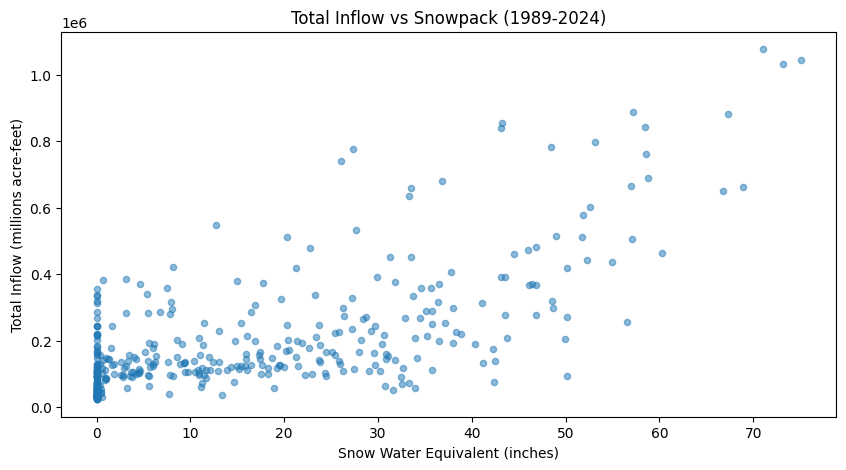

In [31]:
#check how much snowpack data is missing 
print(gsl_monthly_df['snow_water_equiv_in'].isna().sum(), 'missing values')
print(gsl_monthly_df['snow_water_equiv_in'].notna().sum(), 'available values')

#find date range of snowpack data available
snowpack_data = gsl_monthly_df[gsl_monthly_df['snow_water_equiv_in'].notna()]
print('Start date:', snowpack_data['date'].min())
print('End date:', snowpack_data['date'].max())

#filter only rows where snowpack data exists
snow_df = gsl_monthly_df.dropna(subset = ['snow_water_equiv_in'])
#scatter plot of snowpack vs total inflow
snow_df.plot.scatter(
    x = 'snow_water_equiv_in',
    y = 'total_inflow_cfs_acft',
    figsize = (10, 5),
    title = 'Total Inflow vs Snowpack (1989-2024)',
    alpha = 0.5
)
plt.xlabel('Snow Water Equivalent (inches)')
plt.ylabel('Total Inflow (millions acre-feet)')
plt.show()

In [32]:
import pandas as pd
gsl_monthly_df = pd.read_csv('gsl_monthly_df.csv')
gsl_monthly_df.head()

,date,year,month,elevation_ft,monthly_precip_in,snow_water_equiv_in,volume_acft,SA_ac,SA_prior_month_ac,prior_month_vol_acft,precip_acft,total_inflow_cfs_acft,evaporation_acft,bear_river_acft,weber_river_acft,jordan_river_surplus_acft,jordan_river_1700_acft
0,1950-02-01,1950,2,4197.40,1.19,NaN,13231625.08,879251.73,864498.36,13013628.81,85729.420700,330234.8985,197968.049200,144101.275,36621.3605,11994.2245,7142.5835
1,1950-03-01,1950,3,4197.90,0.98,NaN,13677742.99,905185.46,879251.73,13231625.08,71805.557950,378388.3280,4075.975950,161080.035,60738.7370,11591.5740,7025.5570
2,1950-04-01,1950,4,4198.15,1.29,NaN,13905660.50,918138.01,905185.46,13677742.99,97307.436950,607916.9645,477306.891450,228618.210,144858.9720,11311.9005,7144.5670
3,1950-05-01,1950,5,4198.35,2.18,NaN,14090506.69,928507.42,918138.01,13905660.50,166795.071817,811463.7345,793412.616317,288876.940,230403.3600,14786.9925,7263.5770
4,1950-06-01,1950,6,4198.80,0.16,NaN,14513327.20,951733.99,928507.42,14090506.69,12380.098933,571448.3335,161007.922433,220446.190,123647.4230,15227.3295,7688.0460


In [33]:
# creating new dataframe with selected features for the 1950 model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

gsl_monthly_df = pd.read_csv('gsl_monthly_df.csv')

gsl_monthly_df['date'] = pd.to_datetime(gsl_monthly_df['date'])
gsl_monthly_df = gsl_monthly_df.sort_values('date').reset_index(drop=True)

gsl_monthly_df['elevation_change_ft'] = gsl_monthly_df['elevation_ft'].diff()

features50 = [
    'month',
    'elevation_ft',
    'total_inflow_cfs_acft',
    'precip_acft',
    'evaporation_acft'
]

model50 = gsl_monthly_df[['date'] + features50 + ['elevation_change_ft']].dropna()
model50 = model50.reset_index(drop=True)

In [34]:
model50.head(20)

,date,month,elevation_ft,total_inflow_cfs_acft,precip_acft,evaporation_acft,elevation_change_ft
0,1950-03-01,3,4197.90,378388.3280,71805.557950,4075.975950,0.50
1,1950-04-01,4,4198.15,607916.9645,97307.436950,477306.891450,0.25
2,1950-05-01,5,4198.35,811463.7345,166795.071817,793412.616317,0.20
3,1950-06-01,6,4198.80,571448.3335,12380.098933,161007.922433,0.45
4,1950-07-01,7,4198.65,274397.3900,84069.835783,500567.265783,-0.15
5,1950-08-01,8,4198.30,191770.7305,2360.107275,521484.087775,-0.35
6,1950-09-01,9,4197.90,223824.0905,133490.608883,723445.619383,-0.40
7,1950-10-01,10,4197.55,324006.7085,43750.630567,681474.909067,-0.35
8,1950-11-01,11,4197.60,335838.2860,147847.928333,439009.464333,0.05
9,1950-12-01,12,4197.90,384457.8380,36324.110375,151741.128375,0.30


In [35]:
# creating new dataframe with selected features for the 1989 model
features89 = [
    'month',
    'elevation_ft',
    'snow_water_equiv_in',
    'total_inflow_cfs_acft',
    'precip_acft',
    'evaporation_acft'
]

model89 = gsl_monthly_df[['date'] + features89 + ['elevation_change_ft']].dropna()
model89 = model89.reset_index(drop=True)
model89.head(20)

,date,month,elevation_ft,snow_water_equiv_in,total_inflow_cfs_acft,precip_acft,evaporation_acft,elevation_change_ft
0,1989-09-01,9,4204.25,0.0,48942.862500,52031.363358,606520.195858,-0.40
1,1989-10-01,10,4203.74,0.0,71338.032067,190318.117383,894742.259450,-0.51
2,1989-11-01,11,4203.70,1.9,131609.192000,74775.793742,255564.315742,-0.04
3,1989-12-01,12,4203.70,9.4,136129.588500,13285.137342,149414.725842,0.00
4,1990-01-01,1,4203.71,11.0,156756.005000,58250.217575,203021.652575,0.01
5,1990-02-01,2,4203.75,19.2,116758.727500,35819.900375,103378.427875,0.04
6,1990-03-01,3,4203.95,25.4,157158.655500,222337.530917,132459.976417,0.20
7,1990-04-01,4,4203.89,32.7,119503.891500,117770.730500,311587.182000,-0.06
8,1990-05-01,5,4203.72,34.0,57426.292000,169905.107625,436660.489625,-0.17
9,1990-06-01,6,4203.46,11.1,61760.239500,67565.133350,447275.112850,-0.26


## VIF Analysis for GSL

VIF investigates multicollinearity. If more two or more variables explain the same data the model is at risk of overfitting. VIF is used here as a precaution to not overfit.

In [36]:
import numpy as np
from sklearn.linear_model import LinearRegression

pred_vars = [
    'monthly_precip_in',
    'total_inflow_cfs_acft',
    'evaporation_acft',
    'snow_water_equiv_in'
]

# VIF 
tmp = gsl_monthly_df[pred_vars].dropna()
print(f"Rows used (complete cases): {len(tmp)}")
print("  Note: snow_water_equiv_in has ~53% missing — this limits the sample.\n")

vif_rows = []
for col in pred_vars:
    X_other = tmp.drop(columns=[col]).values
    r2  = LinearRegression().fit(X_other, tmp[col].values).score(X_other, tmp[col].values)
    vif = 1 / (1 - r2) if r2 < 0.9999 else np.inf
    vif_rows.append({
        'variable': col,
        'R²':       round(r2, 3),
        'VIF':      round(vif, 1),
        'flag':     'SEVERE' if vif > 10 else ('Moderate' if vif > 5 else 'OK')
    })

vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
print("── VIF Table ─────────────────────────────────────────────────────")
print(vif_df.to_string(index=False))

# High-correlation pairs 
corr = tmp.corr().round(2)
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = (corr.where(mask).stack().reset_index()
              .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'r'}))
print("\n── High-correlation pairs (|r| > 0.40) ──────────────────────────")
high_corr = pairs[pairs['r'].abs() > 0.40].sort_values('r', key=abs, ascending=False)
print(high_corr.to_string(index=False) if not high_corr.empty else "  None found.")

Rows used (complete cases): 424
  Note: snow_water_equiv_in has ~53% missing — this limits the sample.

── VIF Table ─────────────────────────────────────────────────────
             variable    R²  VIF flag
  snow_water_equiv_in 0.599  2.5   OK
total_inflow_cfs_acft 0.563  2.3   OK
    monthly_precip_in 0.173  1.2   OK
     evaporation_acft 0.171  1.2   OK

── High-correlation pairs (|r| > 0.40) ──────────────────────────
                 var1                var2    r
total_inflow_cfs_acft snow_water_equiv_in 0.72
